In [3]:
import sys
sys.path.insert(0, "..")

import torch, json
import src.kz_ml as kzml

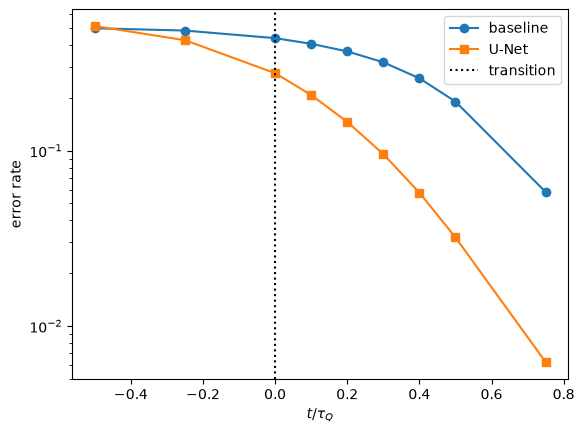

In [8]:
import glob, json
import numpy as np
import matplotlib.pyplot as plt

rows = [json.load(open(f)) for f in glob.glob("../results/tau32_t*.json")]
rows.sort(key=lambda r: r["t_used"])

t    = np.array([r["t_used"]   for r in rows])
base = np.array([r["baseline"] for r in rows])
acc  = np.array([r["test_acc"] for r in rows])

plt.semilogy(t/32, 1-base, "o-", label="baseline")
plt.semilogy(t/32, 1-acc,  "s-", label="U-Net")
plt.axvline(0, color="k", ls=":", label="transition")
plt.xlabel("$t/\\tau_Q$"); plt.ylabel("error rate"); plt.legend()
plt.show()

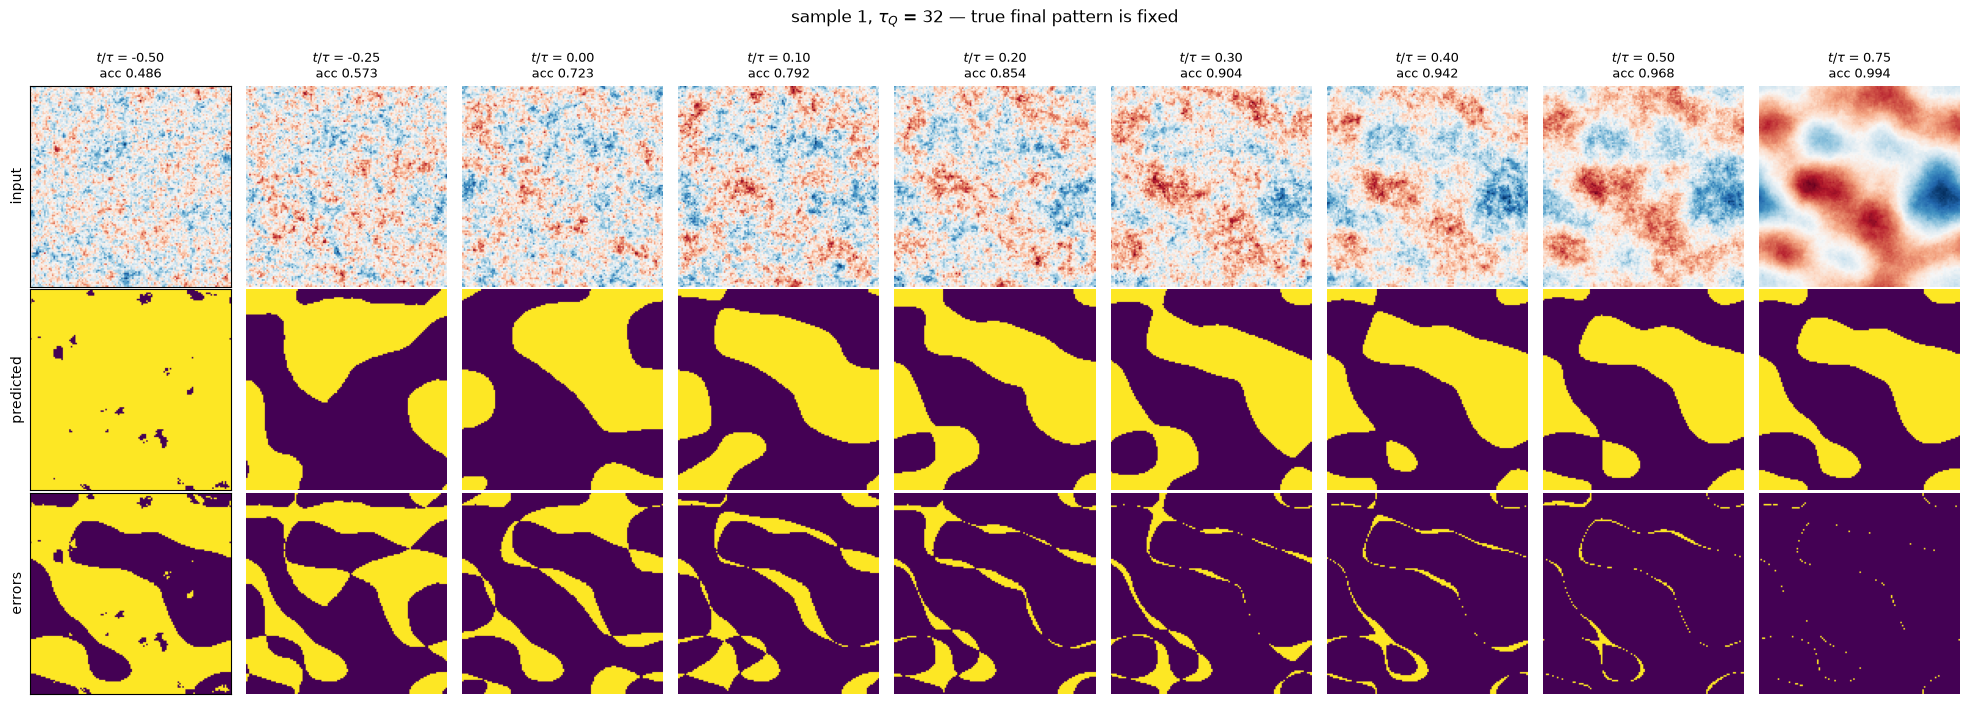

In [ ]:
import sys; sys.path.insert(0, "..")
import glob, json, re
import numpy as np
import matplotlib.pyplot as plt
import torch
import src.kz_ml as kzml

SAMPLE = 1                                   # which sample to follow
TAU    = 64

# every model we trained, sorted by input time
tags = sorted(
    (json.load(open(f))["t_used"], f.replace(".json", ""))
    for f in glob.glob(f"../results/tau{TAU}_t*.json")
    if glob.glob(f.replace(".json", ".pt"))
)

d = np.load(f"../data/2D_tau{TAU}/chunk_000.npz")
Y = (d["phi_final"] > 0)[SAMPLE]

n = len(tags)
fig, axes = plt.subplots(3, n, figsize=(2.2*n, 7))

for col, (t_used, tag) in enumerate(tags):
    r     = json.load(open(tag + ".json"))
    model = kzml.UNet()
    model.load_state_dict(torch.load(tag + ".pt", map_location="cpu"))
    model.eval()

    i = int(np.argmin(np.abs(d["snap_times"] - t_used)))
    x = d["snaps"][SAMPLE, i]

    with torch.no_grad():
        pred = (model(torch.from_numpy(x[None, None] / r["scale"])) > 0).numpy()[0, 0]

    axes[0, col].imshow(x, cmap="RdBu")
    axes[0, col].set_title(f"$t/\\tau$ = {t_used/TAU:.2f}\nacc {r['test_acc']:.3f}", fontsize=9)
    axes[1, col].imshow(pred)
    axes[2, col].imshow(pred != Y)

for ax in axes.ravel():
    ax.axis("off")
axes[0, 0].set_ylabel("input");      axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel("predicted");  axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
axes[2, 0].set_ylabel("errors");     axes[2, 0].axis("on"); axes[2, 0].set_xticks([]); axes[2, 0].set_yticks([])

plt.suptitle(f"sample {SAMPLE}, $\\tau_Q$ = {TAU} — true final pattern is fixed", y=1.0)
plt.tight_layout()
plt.savefig(f"../figures/evolution_tau{TAU}_s{SAMPLE}.png", dpi=150)
plt.show()